<a href="https://colab.research.google.com/github/pranshu789/Cavities/blob/main/Beta(omega).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Short Pulses in Optical Resonator

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid


Parameters and configurationg

In [3]:
c=2.99792458e8

# laser $ cavity setup
lambda_0=1040.0e-9  # central wavelngth
nu_0=c/lambda_0
omega_0=2.0*np.pi*nu_0
tau_inc = 150.0e-15   # 150 fs input pulse

L_cavity = 3.0  #in m
T_rt = L_cavity / c   # rt time in seconds
FSR = 1.0 / T_rt      # FSR in Hz

# just the types of mirrors in the cavity
count_flat=3
count_curved=2
count_ic =1

# GDD parameters
#frequency grid setup -50 to +50 THz ()
num_points = 2**24
omega_max = 2.0 * np.pi * 100.0e12
Omega = np.linspace(-omega_max, omega_max, num_points)
d_Omega = Omega[1] - Omega[0]

# wvlngth grid corresponding to the frequency grid (in nm)
wavelength_grid_nm = (c / (nu_0 + Omega / (2.0 * np.pi))) * 1e9


Reflectivity profiles:


*   use values from the csv for flat and curved mirrors (Optoman)
*   use values from the graph for IC (LayerTech)



In [4]:
fc_nodes_nm = np.array([1010.0, 1020.0, 1030.0, 1040.0, 1050.0, 1060.0, 1070.0])
fc_nodes_R = np.array([0.99966, 0.99969, 0.99970, 0.99969, 0.99967, 0.99962, 0.99955])
R_fc_grid = np.interp(wavelength_grid_nm, fc_nodes_nm, fc_nodes_R)

# internal mirrors reflection product (5 mirrors: 3 flat + 2 curved)
R_internal = R_fc_grid**(count_flat + count_curved)

# IC profile
ic_nodes_nm = np.array([1010.0, 1050.0, 1070.0])
ic_nodes_R = np.array([0.9983, 0.9984, 0.9978])
R_ic_grid = np.interp(wavelength_grid_nm, ic_nodes_nm, ic_nodes_R)

# total rt intensity reflectivity magnitude across all 6 mirrors
R_roundtrip = R_internal * R_ic_grid

GDD profiles.... took em from the graphs:


*   fc: flat & curved mirrors: +8 fs^2 at 1010 nm, 0 at 1030 nm, -8 fs^2 at 1070 nm
*   ic: input coupler (IC): +8 fs^2 at 1010 nm, ~0 at 1040/1050 nm, -6 fs^2 at 1070 nm



First we just try to simulate with a 150fs pulse, then we can scan the pulse duration to see...

In [5]:
gdd_fc_nodes_nm = np.array([1010.0, 1030.0, 1070.0])
gdd_fc_nodes_fs2 = np.array([6.0, 0.0, -8.0])
gdd_fc_fs2 = np.interp(wavelength_grid_nm, gdd_fc_nodes_nm, gdd_fc_nodes_fs2)

gdd_ic_nodes_nm = np.array([1010.0, 1050.0, 1070.0])
gdd_ic_nodes_fs2 = np.array([8.0, 0.0, -6.0])
gdd_ic_fs2 = np.interp(wavelength_grid_nm, gdd_ic_nodes_nm, gdd_ic_nodes_fs2)

total_gdd_s2 = ((count_flat + count_curved) * gdd_fc_fs2 + count_ic * gdd_ic_fs2) * 1e-30

#double integration using trapezoidal rule
p1 = cumulative_trapezoid(total_gdd_s2, Omega, initial=0.0)
p2 = cumulative_trapezoid(p1, Omega, initial=0.0)

center_idx = num_points // 2
delta_phi = p2-p2[center_idx]-Omega*p1[center_idx] #+ Omega * T_rt #(delta_phi(omega)= phi(omega)- phi(0) - omega*phi' + travel phase


Cavity Transfer function and Coupling Beta parameter

In [6]:
sqrt_R_rt = np.sqrt(R_roundtrip)
denominator = 1.0 - sqrt_R_rt * np.exp(1j * delta_phi)

beta_omega = ((1.0 - R_ic_grid) * (1.0 - R_internal)) / np.abs(denominator)**2


#cavity finesse at central wavelength
R_rt_center = R_roundtrip[center_idx]
finesse_exact = (np.pi * np.sqrt(R_rt_center)) / (1.0 - R_rt_center)
print(f"cavity finesse at 1040 nm: {finesse_exact:.1f}")

cavity finesse at 1040 nm: 989.0


Chirping of the pulse

In [7]:
#set-up the fourier transform properly
dt = np.pi / omega_max #calculaes the precise time step resolution aka Nyquist Sampling Theorem
t = (np.arange(num_points) - num_points / 2) * dt #symmetric, zero-centered time array

E_inc_omega = np.exp(- (Omega * tau_inc)**2 / (8.0 * np.log(2.0))) #input pulse directly in frequency domain

#circulating the pulse
input_coupling_factor = np.sqrt(1.0 - R_ic_grid)
E_circ_omega = input_coupling_factor * E_inc_omega / denominator

#convert back to time domain
E_circ_t = np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(E_circ_omega)))
P_circ = np.abs(E_circ_t)**2

# Peak-centered FWHM calculation for circulating pulse
peak_idx = np.argmax(P_circ)
half_max = P_circ[peak_idx] / 2.0

left_idx = peak_idx
while left_idx > 0 and P_circ[left_idx] > half_max:
    left_idx -= 1

right_idx = peak_idx
while right_idx < len(P_circ) - 1 and P_circ[right_idx] > half_max:
    right_idx += 1

tau_circ = t[right_idx] - t[left_idx]

print(f"-> Target Input Variable: {tau_inc * 1e15:.2f} fs")
print(f"-> Circulating Pulse Duration (FWHM): {tau_circ * 1e15:.2f} fs")


-> Target Input Variable: 150.00 fs
-> Circulating Pulse Duration (FWHM): 170.00 fs


Plotting

645.2542019755234


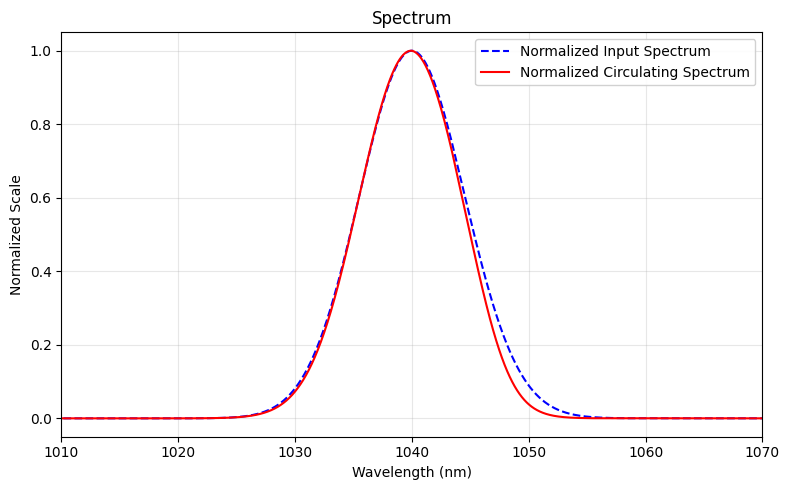

In [8]:
P_inc_spec = np.abs(E_inc_omega)**2
r1=np.max(P_inc_spec)
P_inc_spec /= np.max(P_inc_spec)

P_circ_spec = np.abs(E_circ_omega)**2
r2=np.max(P_circ_spec)
P_circ_spec /= np.max(P_circ_spec)

print(r2/r1)

plt.figure(figsize=(8, 5))
plt.plot(wavelength_grid_nm, P_inc_spec, color='blue', ls='--', lw=1.5, label='Normalized Input Spectrum')
plt.plot(wavelength_grid_nm, P_circ_spec, color='red', lw=1.5, label='Normalized Circulating Spectrum')

plt.title('Spectrum')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Normalized Scale')
plt.xlim(1010, 1070)
plt.ylim(-0.05, 1.05)
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

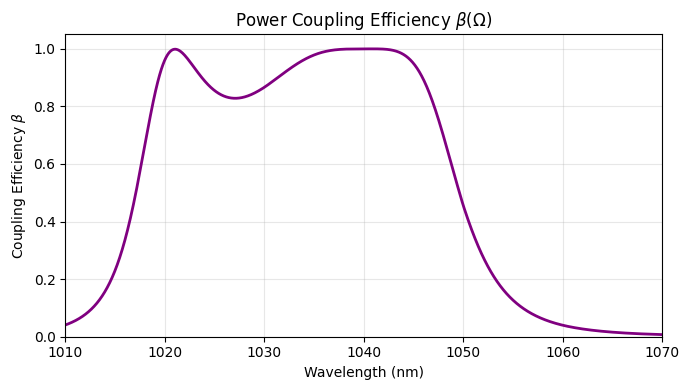

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(wavelength_grid_nm, beta_omega, color='purple', lw=2)
plt.title('Power Coupling Efficiency $\\beta(\\Omega)$')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Coupling Efficiency $\\beta$')
plt.xlim(1010, 1070)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()